In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("shop_smart_ecommerce.csv")
df.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  object 
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  
 13  Region                   12330 non-null  int64  
 14  TrafficType           

* EDA

<Axes: xlabel='Month', ylabel='Revenue'>

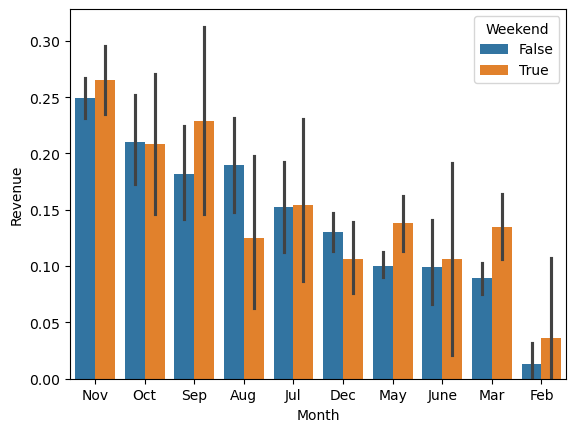

In [4]:
order = df.groupby("Month")["Revenue"].mean().sort_values(ascending=False).index

sns.barplot(
    data=df,
    x="Month",
    y="Revenue",
    hue="Weekend",
    order=order
)

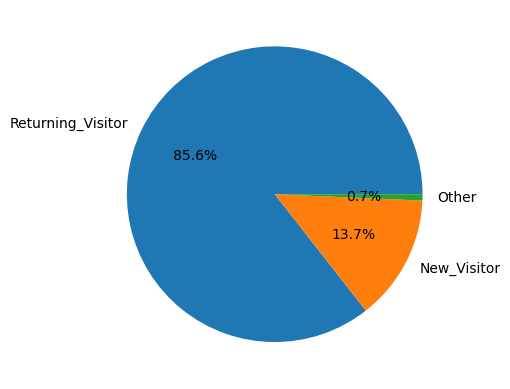

In [5]:
counts = df["VisitorType"].value_counts()

plt.pie(counts, labels=counts.index, autopct='%1.1f%%')
plt.show()

<Axes: xlabel='SpecialDay', ylabel='TrafficType'>

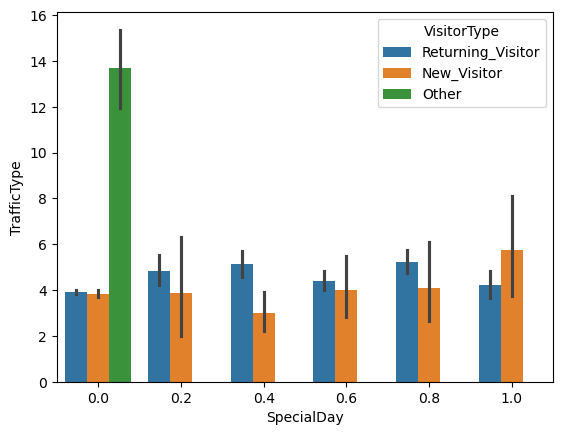

In [6]:
sns.barplot(
    data = df,
    x = "SpecialDay",
    y = "TrafficType",
    hue ="VisitorType"
)

* Featre Encoding

In [7]:
from sklearn.preprocessing import OneHotEncoder, LabelEncoder

In [8]:
cat_col = df.select_dtypes(include=["object"])
num_col = df.select_dtypes(include=["int64", "float64"])

In [9]:
le = LabelEncoder()

df["VisitorType"] = le.fit_transform(df["VisitorType"])

In [10]:
df_temp = df.copy()

In [11]:
ohe = OneHotEncoder(drop="first", handle_unknown="ignore", sparse_output=False)

encoded = ohe.fit_transform(df_temp[["Month"]])

encoded_df = pd.DataFrame(
    encoded,
    columns=ohe.get_feature_names_out(["Month"])
)

df = pd.concat([df_temp, encoded_df], axis=1)

df.drop("Month", axis=1, inplace=True)

In [12]:
df.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,...,Revenue,Month_Dec,Month_Feb,Month_Jul,Month_June,Month_Mar,Month_May,Month_Nov,Month_Oct,Month_Sep
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,...,False,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,...,False,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,...,False,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,...,False,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,...,False,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 26 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  OperatingSystems         12330 non-null  int64  
 11  Browser                  12330 non-null  int64  
 12  Region                   12330 non-null  int64  
 13  TrafficType              12330 non-null  int64  
 14  VisitorType           

In [14]:
df["Revenue"] = df["Revenue"].astype(int)
df["weekend"] = df["Weekend"].astype(int)

* Checking relation

In [15]:
num_col = df.select_dtypes("number")
corr_mat = num_col.corr()

In [16]:
corr_mat

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,...,Month_Dec,Month_Feb,Month_Jul,Month_June,Month_Mar,Month_May,Month_Nov,Month_Oct,Month_Sep,weekend
Administrative,1.000000,0.601583,0.376850,0.255848,0.431119,0.373939,-0.223563,-0.316483,0.098990,-0.094778,...,-0.014443,-0.065649,0.006221,-0.001902,-0.055036,-0.064587,0.051574,0.091266,0.059607,0.026417
Administrative_Duration,0.601583,1.000000,0.302710,0.238031,0.289087,0.355422,-0.144170,-0.205798,0.067608,-0.073304,...,-0.004990,-0.044524,-0.002096,-0.018974,-0.023198,-0.039318,0.032432,0.055101,0.031313,0.014990
Informational,0.376850,0.302710,1.000000,0.618955,0.374164,0.387505,-0.116114,-0.163666,0.048632,-0.048219,...,0.002822,-0.040372,0.001896,0.007176,-0.027957,-0.038422,0.063754,-0.002619,0.009692,0.035785
Informational_Duration,0.255848,0.238031,0.618955,1.000000,0.280046,0.347364,-0.074067,-0.105276,0.030861,-0.030577,...,0.010314,-0.028060,0.014958,-0.015407,-0.011545,-0.031811,0.036899,0.006434,0.001744,0.024078
ProductRelated,0.431119,0.289087,0.374164,0.280046,1.000000,0.860927,-0.204578,-0.292526,0.056282,-0.023958,...,-0.033909,-0.056863,0.020034,0.015072,-0.114672,-0.072220,0.182339,0.008907,0.005997,0.016092
ProductRelated_Duration,0.373939,0.355422,0.387505,0.347364,0.860927,1.000000,-0.184541,-0.251984,0.052823,-0.036380,...,-0.017563,-0.046550,0.002276,0.001506,-0.085491,-0.068133,0.166951,-0.008773,0.005950,0.007311
BounceRates,-0.223563,-0.144170,-0.116114,-0.074067,-0.204578,-0.184541,1.000000,0.913004,-0.119386,0.072702,...,-0.016999,0.063030,0.009766,0.041178,-0.004090,0.059062,-0.034281,-0.046044,-0.040081,-0.046514
ExitRates,-0.316483,-0.205798,-0.163666,-0.105276,-0.292526,-0.251984,0.913004,1.000000,-0.174498,0.102242,...,-0.014700,0.078709,0.008852,0.048276,0.013439,0.072815,-0.056810,-0.062465,-0.050956,-0.062587
PageValues,0.098990,0.067608,0.048632,0.030861,0.056282,0.052823,-0.119386,-0.174498,1.000000,-0.063541,...,0.020518,-0.033137,-0.018317,-0.020804,-0.044451,-0.015099,0.037856,0.032046,0.017439,0.012002
SpecialDay,-0.094778,-0.073304,-0.048219,-0.030577,-0.023958,-0.036380,0.072702,0.102242,-0.063541,1.000000,...,-0.124635,0.106596,-0.058845,-0.047759,-0.132095,0.464809,-0.175039,-0.066666,-0.059966,-0.016767


In [17]:
num_col.corr()["Revenue"].sort_values(ascending=False)

Revenue                    1.000000
PageValues                 0.492569
ProductRelated             0.158538
Month_Nov                  0.154774
ProductRelated_Duration    0.152373
Administrative             0.138917
Informational              0.095200
Administrative_Duration    0.093587
Informational_Duration     0.070345
Month_Oct                  0.032666
weekend                    0.029295
Browser                    0.023984
Month_Sep                  0.019983
Month_Jul                 -0.001036
TrafficType               -0.005113
Region                    -0.011595
OperatingSystems          -0.014668
Month_June                -0.023112
Month_Dec                 -0.033112
Month_Feb                 -0.047114
Month_Mar                 -0.063941
Month_May                 -0.078320
SpecialDay                -0.082305
VisitorType               -0.104726
BounceRates               -0.150673
ExitRates                 -0.207071
Name: Revenue, dtype: float64

In [18]:
df["Revenue"].unique()

array([0, 1])

* Feature Scaling

In [19]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

In [20]:
X = df.drop(columns=["Revenue"])
y = df["Revenue"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

* Model Training

In [21]:
from sklearn.metrics import accuracy_score, precision_score, f1_score, recall_score, confusion_matrix

In [22]:
# LogisticRegression model

from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(class_weight='balanced') # for imbalance dataset

lr_model.fit(X_train_scaled, y_train)

y_pred = lr_model.predict(X_test_scaled)

In [23]:
print("Training_Accracy : ",accuracy_score(y_train, lr_model.predict(X_train_scaled)))
print("Testing_Accracy : ",accuracy_score(y_test, y_pred))
print("precision_score : ",precision_score(y_test, y_pred))
print("recall_score : ",recall_score(y_test, y_pred))
print("f1_score : ",f1_score(y_test, y_pred))
print("confusion_matrix : \n",confusion_matrix(y_test, y_pred))

Training_Accracy :  0.8542463213996061
Testing_Accracy :  0.8521221951878886
precision_score :  0.5165094339622641
recall_score :  0.7617391304347826
f1_score :  0.6156008432888265
confusion_matrix : 
 [[2714  410]
 [ 137  438]]


In [24]:
# With pipeline

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)


pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("lr", LogisticRegression(class_weight='balanced')) # for imbalance dataset
])

param_grid_lr = {
    "lr__C": [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100]
}

lr_model_cv = GridSearchCV(
    pipeline,
    param_grid=param_grid_lr,
    cv = 5
)

lr_model_cv.fit(X_train, y_train)
y_pred = lr_model_cv.predict(X_test)

In [25]:
print("Training_Accracy : ",accuracy_score(y_train, lr_model_cv.predict(X_train)))
print("Testing_Accracy : ",accuracy_score(y_test, y_pred))
print("precision_score : ",precision_score(y_test, y_pred))
print("recall_score : ",recall_score(y_test, y_pred))
print("f1_score : ",f1_score(y_test, y_pred))
print("confusion_matrix : \n",confusion_matrix(y_test, y_pred))

Training_Accracy :  0.853898737110416
Testing_Accracy :  0.8521221951878886
precision_score :  0.5165094339622641
recall_score :  0.7617391304347826
f1_score :  0.6156008432888265
confusion_matrix : 
 [[2714  410]
 [ 137  438]]


In [26]:
# KNN

from sklearn.neighbors import KNeighborsClassifier

knn_model = KNeighborsClassifier()

knn_model.fit(X_train_scaled, y_train)

y_pred = knn_model.predict(X_test_scaled)

In [27]:
print("Training_Accracy : ",accuracy_score(y_train, knn_model.predict(X_train_scaled)))
print("Testing_Accracy : ",accuracy_score(y_test, y_pred))
print("precision_score : ",precision_score(y_test, y_pred))
print("recall_score : ",recall_score(y_test, y_pred))
print("f1_score : ",f1_score(y_test, y_pred))
print("confusion_matrix : \n",confusion_matrix(y_test, y_pred))

Training_Accracy :  0.9008226161510833
Testing_Accracy :  0.8718572587185726
precision_score :  0.6655737704918033
recall_score :  0.35304347826086957
f1_score :  0.46136363636363636
confusion_matrix : 
 [[3022  102]
 [ 372  203]]


In [28]:
# Using Pipeline

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier())
])

param_grid_knn = {
    "knn__n_neighbors" : [3, 5, 7, 9, 11, 13, 15, 17, 19, 21],
    "knn__weights": ["uniform", "distance"]
}

knn_model_cv = GridSearchCV(
    pipeline,
    param_grid=param_grid_knn,
    cv = 5,
    scoring="f1"
)

knn_model_cv.fit(X_train, y_train)
y_pred = knn_model_cv.predict(X_test)

In [29]:
print("Training_Accracy : ",accuracy_score(y_train, knn_model_cv.predict(X_train)))
print("Testing_Accracy : ",accuracy_score(y_test, y_pred))
print("precision_score : ",precision_score(y_test, y_pred))
print("recall_score : ",recall_score(y_test, y_pred))
print("f1_score : ",f1_score(y_test, y_pred))
print("confusion_matrix : \n",confusion_matrix(y_test, y_pred))

Training_Accracy :  1.0
Testing_Accracy :  0.8715869153825359
precision_score :  0.6592356687898089
recall_score :  0.36
f1_score :  0.46569178852643417
confusion_matrix : 
 [[3017  107]
 [ 368  207]]


In [30]:
# Naive Bayes

from sklearn.naive_bayes import GaussianNB

nb_model = GaussianNB()

nb_model.fit(X_train, y_train)
y_pred = nb_model.predict(X_test)

In [31]:
print("Training_Accracy : ",accuracy_score(y_train, nb_model.predict(X_train)))
print("Testing_Accracy : ",accuracy_score(y_test, y_pred))
print("precision_score : ",precision_score(y_test, y_pred))
print("recall_score : ",recall_score(y_test, y_pred))
print("f1_score : ",f1_score(y_test, y_pred))
print("confusion_matrix : \n",confusion_matrix(y_test, y_pred))

Training_Accracy :  0.7986328351291855
Testing_Accracy :  0.7964314679643146
precision_score :  0.4026258205689278
recall_score :  0.64
f1_score :  0.49429147078576224
confusion_matrix : 
 [[2578  546]
 [ 207  368]]


In [32]:
# with cross-validation

param_grid_nb = {
    "var_smoothing" : [1e-12, 1e-11, 1e-10, 1e-9, 1e-8, 1e-7, 1e-6, 1e-5, 1e-4, 1e-3, 1e-2]
}

nb_model_cv = GridSearchCV(
    estimator=GaussianNB(),
    param_grid=param_grid_nb,
    cv = 5,
    scoring="f1"
)

nb_model_cv.fit(X_train, y_train)
y_pred = nb_model_cv.predict(X_test)

In [33]:
print("Training_Accracy : ",accuracy_score(y_train, nb_model_cv.predict(X_train)))
print("Testing_Accracy : ",accuracy_score(y_test, y_pred))
print("precision_score : ",precision_score(y_test, y_pred))
print("recall_score : ",recall_score(y_test, y_pred))
print("f1_score : ",f1_score(y_test, y_pred))
print("confusion_matrix : \n",confusion_matrix(y_test, y_pred))

Training_Accracy :  0.8490325570617542
Testing_Accracy :  0.850500135171668
precision_score :  0.5195035460992907
recall_score :  0.5095652173913043
f1_score :  0.514486391571554
confusion_matrix : 
 [[2853  271]
 [ 282  293]]


In [34]:
# Decision Tree

from sklearn.tree import DecisionTreeClassifier
dt_model = DecisionTreeClassifier(class_weight="balanced", random_state=42)

dt_model.fit(X_train, y_train)
y_pred = dt_model.predict(X_test)

In [35]:
print("Training_Accracy : ",accuracy_score(y_train, dt_model.predict(X_train)))
print("Testing_Accracy : ",accuracy_score(y_test, y_pred))
print("precision_score : ",precision_score(y_test, y_pred))
print("recall_score : ",recall_score(y_test, y_pred))
print("f1_score : ",f1_score(y_test, y_pred))
print("confusion_matrix : \n",confusion_matrix(y_test, y_pred))

Training_Accracy :  1.0
Testing_Accracy :  0.8696945120302785
precision_score :  0.5828877005347594
recall_score :  0.568695652173913
f1_score :  0.5757042253521126
confusion_matrix : 
 [[2890  234]
 [ 248  327]]


In [36]:
# with cross-validation

param_grid_dt = {
    "max_depth": [3, 5, 7, 10, 15, 20, None],
    "min_samples_split": [2, 5, 10, 20],
    "min_samples_leaf": [1, 2, 4, 8],
    "criterion": ["gini", "entropy"],
    "class_weight": ["balanced"]
}

dt_model_cv = GridSearchCV(
    estimator=DecisionTreeClassifier(class_weight="balanced", random_state=42),
    param_grid=param_grid_dt,
    cv = 5,
    scoring="f1",
    n_jobs=-1
)

dt_model_cv.fit(X_train, y_train)
y_pred = dt_model_cv.predict(X_test)

In [37]:
print("Training_Accracy : ",accuracy_score(y_train, dt_model_cv.predict(X_train)))
print("Testing_Accracy : ",accuracy_score(y_test, y_pred))
print("precision_score : ",precision_score(y_test, y_pred))
print("recall_score : ",recall_score(y_test, y_pred))
print("f1_score : ",f1_score(y_test, y_pred))
print("confusion_matrix : \n",confusion_matrix(y_test, y_pred))

Training_Accracy :  0.8514656470860851
Testing_Accracy :  0.8472560151392268
precision_score :  0.5051867219917012
recall_score :  0.8469565217391304
f1_score :  0.6328784925276153
confusion_matrix : 
 [[2647  477]
 [  88  487]]


In [38]:
# Random Forest

from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=701,
    n_jobs=1,
    max_depth=4,
    criterion="entropy", # best for imbalance dataset
    class_weight="balanced"
)

rf_model.fit(X_train, y_train)
y_pred = rf_model.predict(X_test)

In [39]:
print("Training_Accracy : ",accuracy_score(y_train, rf_model.predict(X_train)))
print("Testing_Accracy : ",accuracy_score(y_test, y_pred))
print("precision_score : ",precision_score(y_test, y_pred))
print("recall_score : ",recall_score(y_test, y_pred))
print("f1_score : ",f1_score(y_test, y_pred))
print("confusion_matrix : \n",confusion_matrix(y_test, y_pred))

Training_Accracy :  0.8672228015293709
Testing_Accracy :  0.8634766153014328
precision_score :  0.5394144144144144
recall_score :  0.8330434782608696
f1_score :  0.6548188653451812
confusion_matrix : 
 [[2715  409]
 [  96  479]]


In [40]:
# With cross validation

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

param_grid_rf = {
    "n_estimators" : [101, 201, 301, 401, 501, 601, 701],
    "criterion": ["gini", "entropy", "log_loss"],
    "max_depth" : [3, 4, 10, None],
    "min_samples_split": [2, 5, 10],
    "class_weight": ["balanced"]
}

rf_model_cv = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid_rf,
    scoring="f1",
    cv = 5,
    n_jobs=-1
)

rf_model_cv.fit(X_train,y_train)
y_pred = rf_model_cv.predict(X_test)

In [41]:
print("Training_Accracy : ",accuracy_score(y_train, rf_model_cv.predict(X_train)))
print("Testing_Accracy : ",accuracy_score(y_test, y_pred))
print("precision_score : ",precision_score(y_test, y_pred))
print("recall_score : ",recall_score(y_test, y_pred))
print("f1_score : ",f1_score(y_test, y_pred))
print("confusion_matrix : \n",confusion_matrix(y_test, y_pred))

Training_Accracy :  0.978449774070212
Testing_Accracy :  0.8924033522573669
precision_score :  0.6477462437395659
recall_score :  0.6747826086956522
f1_score :  0.6609880749574105
confusion_matrix : 
 [[2913  211]
 [ 187  388]]


In [42]:
# SVC

from sklearn.svm import SVC

svc_model = SVC()

svc_model.fit(X_train_scaled, y_train)

y_pred = svc_model.predict(X_test_scaled)

In [ ]:
print("Training_Accracy : ",accuracy_score(y_train, svc_model.predict(X_train_scaled)))
print("Testing_Accracy : ",accuracy_score(y_test, y_pred))
print("precision_score : ",precision_score(y_test, y_pred))
print("recall_score : ",recall_score(y_test, y_pred))
print("f1_score : ",f1_score(y_test, y_pred))
print("confusion_matrix : \n",confusion_matrix(y_test, y_pred))

c:\Users\prita\miniconda3\envs\ai\lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but SVC was fitted without feature names
  warnings.warn(


Training_Accracy :  0.8455567141698529
Testing_Accracy :  0.8875371722087051
precision_score :  0.7277936962750716
recall_score :  0.44173913043478263
f1_score :  0.5497835497835498
confusion_matrix : 
 [[3029   95]
 [ 321  254]]


In [ ]:
# Using Pipeline

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42,stratify=y
)

pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("svc", SVC(class_weight="balanced"))
])

param = {
    "svc__C": [0.1, 1, 10, 20, 30, 12, 45, 67, 45, 78, 54, 76, 98, 16, 18, 29, 39, 49,100],
    "svc__kernel": ["linear", "rbf"],
    "svc__gamma": ["scale", "auto"]
}

svc_model_cv = GridSearchCV(
    pipeline,
    param_grid=param,
    cv = 5, 
    n_jobs=-1,
    scoring="f1"
)

svc_model_cv.fit(X_train, y_train)
y_pred = svc_model_cv.predict(X_test)

In [ ]:
print("Training_Accracy : ",accuracy_score(y_train, svc_model_cv.predict(X_train)))
print("Testing_Accracy : ",accuracy_score(y_test, y_pred))
print("precision_score : ",precision_score(y_test, y_pred))
print("recall_score : ",recall_score(y_test, y_pred))
print("f1_score : ",f1_score(y_test, y_pred))
print("confusion_matrix : \n",confusion_matrix(y_test, y_pred))

Training_Accracy :  0.878345498783455
Testing_Accracy :  0.8771868844861546
precision_score :  0.5819477434679335
recall_score :  0.7335329341317365
f1_score :  0.6490066225165563
confusion_matrix : 
 [[6591  704]
 [ 356  980]]
